# Compiling and simulating a 10-qubit Quantum Fourier Transform (QFT) algorithm

In this notebook, we simulate a 10-qubit Quantum Fourier Transform (QFT) algorithm.
The QFT algorithm is one of the most important quantum algorithms in quantum computing.
It is, for instance, part of the Shor algorithm for integer factorization.
The following code defines a 10-qubit QFT algorithm using CNOT and single qubit rotations and runs the simulation both at the gate level and at the pulse level.

In [1]:
from qutip import about, basis, fidelity
from qutip_qip.algorithms import qft_gate_sequence
from qutip_qip.device import LinearSpinChain

num_qubits = 10
# The QFT circuit
qc = qft_gate_sequence(num_qubits, swapping=False, to_cnot=True)
# Gate-level simulation
state1 = qc.run(basis([2] * num_qubits, [0] * num_qubits))
# Pulse-level simulation
processor = LinearSpinChain(num_qubits)
processor.load_circuit(qc)
state2 = processor.run_state(basis([2] * num_qubits,
                                   [0] * num_qubits)).states[-1]
fidelity(state1, state2)

np.float64(0.9999315359606872)

We plot the compiled pulses in the cell below.
The pulses plotted implement the QFT algorithm represented in the native gates of the spin chain model, with single-qubit gates marked by rotations over the $x$- and $z$-axes and the iSWAP gate implemented through the spin-spin exchange interaction, marked by $g_i$.
While the sign for single-qubit drive denotes the phase of the control pulse, the negative sign in the coupling strengths $g_i$ is only a result of the convention used in the definition of the interaction, defined in \cref{eq:ham spin chain}.

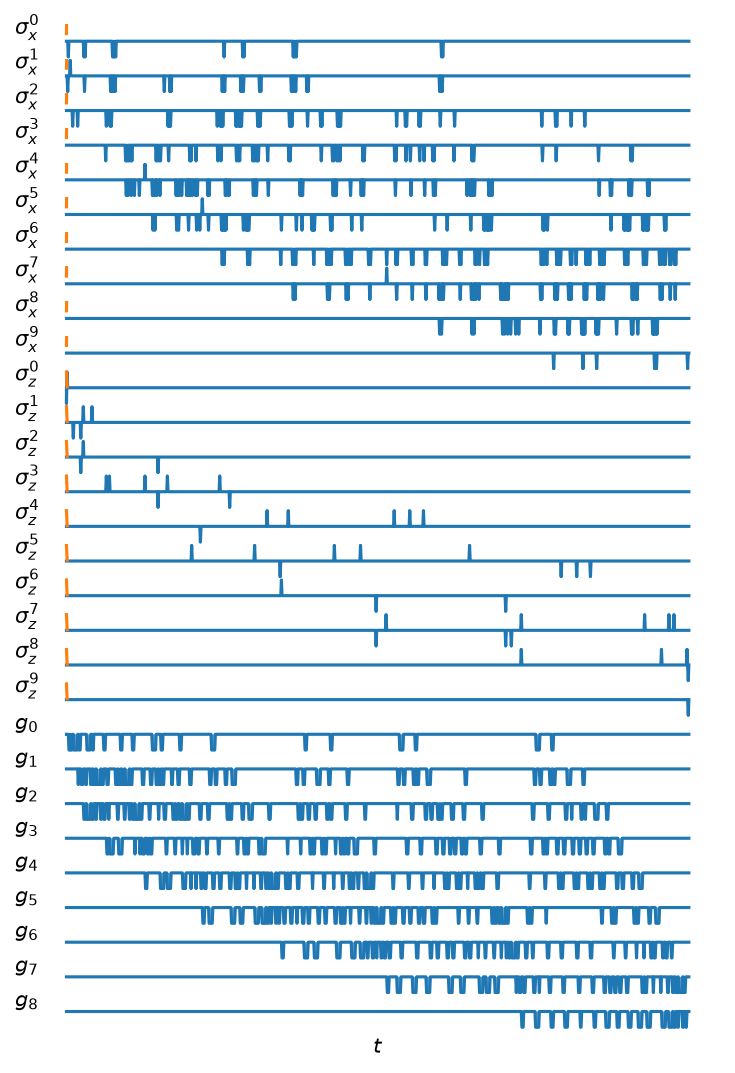

In [2]:
def get_control_latex(model):
    """
    Get the labels for each Hamiltonian.
    It is used in the method method :meth:`.Processor.plot_pulses`.
    It is a 2-d nested list, in the plot,
    a different color will be used for each sublist.
    """
    num_qubits = model.num_qubits
    num_coupling = model._get_num_coupling()
    return [
        {f"sx{m}": r"$\sigma_x^{}$".format(m) for m in range(num_qubits)},
        {f"sz{m}": r"$\sigma_z^{}$".format(m) for m in range(num_qubits)},
        {f"g{m}": r"$g_{}$".format(m) for m in range(num_coupling)},
    ]


fig, axes = processor.plot_pulses(
    figsize=(5, 7), dpi=150, pulse_labels=get_control_latex(processor.model)
)
axes[-1].set_xlabel("$t$");

In [3]:
about()


QuTiP: Quantum Toolbox in Python
Copyright (c) QuTiP team 2011 and later.
Current admin team: Alexander Pitchford, Nathan Shammah, Shahnawaz Ahmed, Neill Lambert, Eric Giguère, Boxi Li, Simon Cross, Asier Galicia, Paul Menczel, and Patrick Hopf.
Board members: Daniel Burgarth, Robert Johansson, Anton F. Kockum, Franco Nori and Will Zeng.
Original developers: R. J. Johansson & P. D. Nation.
Previous lead developers: Chris Granade & A. Grimsmo.
Currently developed through wide collaboration. See https://github.com/qutip for details.

QuTiP Version:      5.3.0
Numpy Version:      2.5.1
Scipy Version:      1.18.0
Cython Version:     3.2.8
Matplotlib Version: 3.11.1
Python Version:     3.12.0
Number of CPUs:     4
BLAS Info:          blas
INTEL MKL Ext:      None
Platform Info:      Linux (x86_64)
Installation path:  /home/runner/miniconda3/envs/test-environment-v5/lib/python3.12/site-packages/qutip

Installed QuTiP family packages
-------------------------------



qutip-qoc: 0.3.0.dev0+1c18818
qutip-jax: 0.1.1.dev8
qutip-qtrl: 0.2.1.dev0+2a34540
qutip-qip: 0.4.2

Please cite QuTiP in your publication.
For your convenience a bibtex reference can be easily generated using `qutip.cite()`
